# London Property Intelligence

## Portfolio Project

### Project Overview

This project analyzes residential property transactions across London's 33 administrative areas using HM Land Registry data.

The analysis explores market activity, property prices, and market opportunities through exploratory data analysis, feature engineering, and business-driven scoring methods.

---

In [1]:
from pathlib import Path

import pandas as pd

In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "pp-2025.csv"
DATA_PATH

WindowsPath('c:/Users/ASUS/projects/london-property-intelligence/data/raw/pp-2025.csv')

In [3]:
df = pd.read_csv(DATA_PATH)

df

,{36A61A94-E202-DEF2-E063-4704A8C046AE},525000,2025-03-21 00:00,OX28 6DJ,D,N,F,44,Unnamed: 8,BURFORD ROAD,Unnamed: 10,WITNEY,WEST OXFORDSHIRE,OXFORDSHIRE,A,A.1
0,{36A61A94-E203-DEF2-E063-4704A8C046AE},251000,2025-04-17 00:00,OX3 7AF,F,N,L,"LIME COURT, 114",FLAT 4,LIME WALK,HEADINGTON,OXFORD,OXFORD,OXFORDSHIRE,A,A
1,{36A61A94-E204-DEF2-E063-4704A8C046AE},180000,2025-04-11 00:00,OX16 9TD,F,N,L,158,NaN,BANKSIDE,NaN,BANBURY,CHERWELL,OXFORDSHIRE,A,A
2,{36A61A94-E205-DEF2-E063-4704A8C046AE},207000,2025-04-04 00:00,OX14 3ZF,F,N,L,166,NaN,THAMES VIEW,NaN,ABINGDON,VALE OF WHITE HORSE,OXFORDSHIRE,A,A
3,{36A61A94-E206-DEF2-E063-4704A8C046AE},117500,2025-04-25 00:00,OX28 1GJ,F,N,L,OTTERS COURT,66,PRIORY MILL LANE,NaN,WITNEY,WEST OXFORDSHIRE,OXFORDSHIRE,A,A
4,{36A61A94-E207-DEF2-E063-4704A8C046AE},355000,2025-04-11 00:00,OX25 2RJ,T,N,F,22,NaN,PLOUGHLEY ROAD,AMBROSDEN,BICESTER,CHERWELL,OXFORDSHIRE,A,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
907688,{38EDC0C3-0727-0F63-E063-4704A8C00424},139950,2025-05-30 00:00,BB1 2LG,T,N,F,64,NaN,BLACKAMOOR ROAD,GUIDE,BLACKBURN,BLACKBURN WITH DARWEN,BLACKBURN WITH DARWEN,A,A
907689,{38EDC0C3-0728-0F63-E063-4704A8C00424},118000,2025-05-28 00:00,FY8 3NF,F,N,L,103,FLAT 3,ST ANNES ROAD EAST,NaN,LYTHAM ST ANNES,FYLDE,LANCASHIRE,A,A
907690,{38EDC0C3-072A-0F63-E063-4704A8C00424},135000,2025-05-30 00:00,LA1 2BJ,T,N,F,74,NaN,PINFOLD LANE,NaN,LANCASTER,LANCASTER,LANCASHIRE,A,A
907691,{38EDC0C3-072B-0F63-E063-4704A8C00424},150000,2025-05-23 00:00,PR3 3TN,T,N,F,22,NaN,PARLICK AVENUE,LONGRIDGE,PRESTON,RIBBLE VALLEY,LANCASHIRE,A,A


In [4]:
df.columns

Index(['{36A61A94-E202-DEF2-E063-4704A8C046AE}', '525000', '2025-03-21 00:00',
       'OX28 6DJ', 'D', 'N', 'F', '44', 'Unnamed: 8', 'BURFORD ROAD',
       'Unnamed: 10', 'WITNEY', 'WEST OXFORDSHIRE', 'OXFORDSHIRE', 'A', 'A.1'],
      dtype='object')

In [5]:
column_names = [
    "Transaction unique identifier",
    "Price",
    "Date of Transfer",
    "Postcode",
    "Property Type",
    "Old/New",
    "Duration",
    "PAON",
    "SAON",
    "Street",
    "Locality",
    "Town/City",
    "District",
    "County",
    "PPD Category Type",
    "Record Status"
]

df = pd.read_csv(
    DATA_PATH,
    header=None,
    names=column_names
)

df.head()

,Transaction unique identifier,Price,Date of Transfer,Postcode,Property Type,Old/New,Duration,PAON,SAON,Street,Locality,Town/City,District,County,PPD Category Type,Record Status
0,{36A61A94-E202-DEF2-E063-4704A8C046AE},525000,2025-03-21 00:00,OX28 6DJ,D,N,F,44,NaN,BURFORD ROAD,NaN,WITNEY,WEST OXFORDSHIRE,OXFORDSHIRE,A,A
1,{36A61A94-E203-DEF2-E063-4704A8C046AE},251000,2025-04-17 00:00,OX3 7AF,F,N,L,"LIME COURT, 114",FLAT 4,LIME WALK,HEADINGTON,OXFORD,OXFORD,OXFORDSHIRE,A,A
2,{36A61A94-E204-DEF2-E063-4704A8C046AE},180000,2025-04-11 00:00,OX16 9TD,F,N,L,158,NaN,BANKSIDE,NaN,BANBURY,CHERWELL,OXFORDSHIRE,A,A
3,{36A61A94-E205-DEF2-E063-4704A8C046AE},207000,2025-04-04 00:00,OX14 3ZF,F,N,L,166,NaN,THAMES VIEW,NaN,ABINGDON,VALE OF WHITE HORSE,OXFORDSHIRE,A,A
4,{36A61A94-E206-DEF2-E063-4704A8C046AE},117500,2025-04-25 00:00,OX28 1GJ,F,N,L,OTTERS COURT,66,PRIORY MILL LANE,NaN,WITNEY,WEST OXFORDSHIRE,OXFORDSHIRE,A,A


In [6]:
df["County"].value_counts().head(30)

County
GREATER LONDON        100841
GREATER MANCHESTER     42248
WEST YORKSHIRE         35422
WEST MIDLANDS          34287
KENT                   25943
ESSEX                  25187
LANCASHIRE             22609
HAMPSHIRE              22443
MERSEYSIDE             21769
SOUTH YORKSHIRE        20478
SURREY                 18586
TYNE AND WEAR          17451
HERTFORDSHIRE          17311
NORFOLK                15988
NOTTINGHAMSHIRE        15018
STAFFORDSHIRE          14576
WEST SUSSEX            14488
DERBYSHIRE             14234
DEVON                  14169
LINCOLNSHIRE           13805
SUFFOLK                13102
LEICESTERSHIRE         12551
GLOUCESTERSHIRE        11590
NORTH YORKSHIRE        11274
OXFORDSHIRE            10901
WARWICKSHIRE           10610
CAMBRIDGESHIRE         10506
COUNTY DURHAM          10073
SOMERSET                9734
WORCESTERSHIRE          9727
Name: count, dtype: int64

## Data Understanding

### Question

Can the **District** column be used to identify London boroughs?

### Why does this matter?

The project focuses exclusively on London property investment.

Before filtering the dataset, we need to verify whether the **District** column contains the geographical information required to identify London boroughs.

### Expected outcome

This analysis will determine whether the **District** column can be used as the primary geographic identifier for constructing the London-only dataset.

## Creating the London Dataset

### Objective

The original HM Land Registry dataset contains transactions from across England and Wales.

Since the scope of this project is limited to London property investment, the first preprocessing step is to isolate London transactions.

### Approach

For Version 1 of the project, London transactions are identified using the `County` field.

Records where:

County = "GREATER LONDON"

will be retained for further analysis.

### Output

The filtered dataset will be saved as:

data/processed/london_transactions.csv

In [7]:
london_df = df[df["County"] == "GREATER LONDON"].copy()

print(f"Number of London transactions: {len(london_df):,}")

london_df.head()

Number of London transactions: 100,841


,Transaction unique identifier,Price,Date of Transfer,Postcode,Property Type,Old/New,Duration,PAON,SAON,Street,Locality,Town/City,District,County,PPD Category Type,Record Status
482,{50D10B84-3BD1-B8D0-E063-4704A8C08D98},555000,2025-10-10 00:00,N22 5NB,T,N,F,28,NaN,ST ALBANS CRESCENT,NaN,LONDON,HARINGEY,GREATER LONDON,A,A
483,{50D10B84-3BD2-B8D0-E063-4704A8C08D98},3000000,2025-11-28 00:00,SW5 0LF,T,N,F,145,NaN,OLD BROMPTON ROAD,NaN,LONDON,KENSINGTON AND CHELSEA,GREATER LONDON,A,A
484,{50D10B84-3BD4-B8D0-E063-4704A8C08D98},420000,2025-11-24 00:00,RM11 1BD,T,N,F,33,NaN,PARK LANE,NaN,HORNCHURCH,HAVERING,GREATER LONDON,A,A
485,{50D10B84-3BD7-B8D0-E063-4704A8C08D98},340000,2025-04-23 00:00,N12 9PN,F,N,L,63,NaN,TORRINGTON PARK,NaN,LONDON,BARNET,GREATER LONDON,A,A
486,{50D10B84-3BDC-B8D0-E063-4704A8C08D98},395000,2025-12-19 00:00,NW10 5JD,F,N,L,64,FIRST FLOOR MAISONETTE,CLIFFORD GARDENS,NaN,LONDON,BRENT,GREATER LONDON,A,A


In [8]:
london_df["County"].value_counts()

County
GREATER LONDON    100841
Name: count, dtype: int64

### Validation

The filtering step was successfully validated.

All records in the filtered dataset belong to:

County = GREATER LONDON

This confirms that the London dataset has been correctly isolated from the original England and Wales transaction data.

In [9]:
london_df["District"].value_counts().head(20)

District
WANDSWORTH              5383
CROYDON                 4914
BROMLEY                 4831
BARNET                  4420
LAMBETH                 4220
HAVERING                3683
EALING                  3622
LEWISHAM                3606
SOUTHWARK               3589
WALTHAM FOREST          3381
ENFIELD                 3320
HILLINGDON              3271
BEXLEY                  3262
TOWER HAMLETS           3227
GREENWICH               3101
RICHMOND UPON THAMES    2917
HARINGEY                2887
REDBRIDGE               2834
CITY OF WESTMINSTER     2814
BRENT                   2749
Name: count, dtype: int64

### Conclusion

The dataset already provides London borough names in the `District` column.

Therefore:

- `County` will be used to filter London transactions.
- `District` will be used for borough-level analysis.

In [10]:
OUTPUT_PATH = PROJECT_ROOT / "data" / "processed" / "london_transactions.csv"

OUTPUT_PATH

WindowsPath('c:/Users/ASUS/projects/london-property-intelligence/data/processed/london_transactions.csv')

In [11]:
london_df.to_csv(OUTPUT_PATH, index=False)

print("London dataset saved successfully.")

London dataset saved successfully.


In [12]:
saved_df = pd.read_csv(OUTPUT_PATH)

saved_df.head()

,Transaction unique identifier,Price,Date of Transfer,Postcode,Property Type,Old/New,Duration,PAON,SAON,Street,Locality,Town/City,District,County,PPD Category Type,Record Status
0,{50D10B84-3BD1-B8D0-E063-4704A8C08D98},555000,2025-10-10 00:00,N22 5NB,T,N,F,28,NaN,ST ALBANS CRESCENT,NaN,LONDON,HARINGEY,GREATER LONDON,A,A
1,{50D10B84-3BD2-B8D0-E063-4704A8C08D98},3000000,2025-11-28 00:00,SW5 0LF,T,N,F,145,NaN,OLD BROMPTON ROAD,NaN,LONDON,KENSINGTON AND CHELSEA,GREATER LONDON,A,A
2,{50D10B84-3BD4-B8D0-E063-4704A8C08D98},420000,2025-11-24 00:00,RM11 1BD,T,N,F,33,NaN,PARK LANE,NaN,HORNCHURCH,HAVERING,GREATER LONDON,A,A
3,{50D10B84-3BD7-B8D0-E063-4704A8C08D98},340000,2025-04-23 00:00,N12 9PN,F,N,L,63,NaN,TORRINGTON PARK,NaN,LONDON,BARNET,GREATER LONDON,A,A
4,{50D10B84-3BDC-B8D0-E063-4704A8C08D98},395000,2025-12-19 00:00,NW10 5JD,F,N,L,64,FIRST FLOOR MAISONETTE,CLIFFORD GARDENS,NaN,LONDON,BRENT,GREATER LONDON,A,A


In [13]:
saved_df.shape

(100841, 16)

In [14]:
df["District"].value_counts().head(20)

District
BIRMINGHAM                             12500
LEEDS                                  12025
NORTH YORKSHIRE                        11274
COUNTY DURHAM                          10073
SOMERSET                                9734
CORNWALL                                9579
BUCKINGHAMSHIRE                         8572
WILTSHIRE                               8309
CHESHIRE EAST                           8071
BRADFORD                                7886
SHEFFIELD                               7281
WEST NORTHAMPTONSHIRE                   7280
DORSET                                  7014
LIVERPOOL                               6915
CITY OF BRISTOL                         6897
EAST RIDING OF YORKSHIRE                6863
BOURNEMOUTH, CHRISTCHURCH AND POOLE     6427
KIRKLEES                                6421
MANCHESTER                              6352
NORTH NORTHAMPTONSHIRE                  6285
Name: count, dtype: int64

# Exploratory Data Analysis (EDA)

## Business Question 1

Which London boroughs have the highest property transaction activity?

### Why does this matter?

Understanding transaction activity helps identify the most active property markets across London. Highly active boroughs may indicate greater market liquidity and provide a useful starting point for investment analysis.

### Expected outcome

Identify the boroughs with the highest number of recorded property transactions.

In [15]:
borough_activity = (
    london_df["District"]
    .value_counts()
    .reset_index()
)

borough_activity.columns = ["Borough", "Transactions"]

borough_activity.head(10)

,Borough,Transactions
0,WANDSWORTH,5383
1,CROYDON,4914
2,BROMLEY,4831
3,BARNET,4420
4,LAMBETH,4220
5,HAVERING,3683
6,EALING,3622
7,LEWISHAM,3606
8,SOUTHWARK,3589
9,WALTHAM FOREST,3381


In [16]:
import matplotlib.pyplot as plt

In [17]:
top10 = borough_activity.head(10)

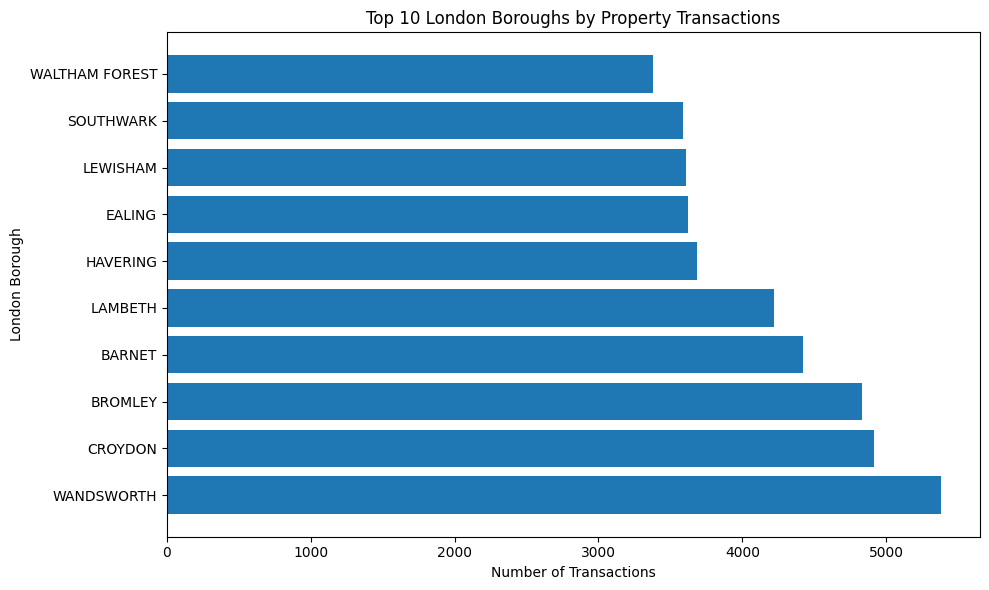

In [18]:
plt.figure(figsize=(10, 6))
plt.barh(
    top10["Borough"],
    top10["Transactions"]
)
plt.xlabel("Number of Transactions")
plt.ylabel("London Borough")
plt.title("Top 10 London Boroughs by Property Transactions")
plt.tight_layout()

plt.show()

## Insight

Wandsworth recorded the highest number of property transactions in the dataset, followed by Croydon and Bromley. This suggests that these boroughs were among the most active property markets during the period covered by the dataset.

However, transaction volume alone should not be interpreted as an indicator of investment attractiveness. A higher number of transactions reflects market activity rather than profitability or future growth potential. Further analysis of property prices, price trends, and other market indicators is required before drawing investment conclusions.

## Business Question 2

### Question

Which London boroughs have the highest average property prices?

### Why does this matter?

Transaction activity shows how active the market is, but it does not indicate property values.

Average property prices provide a clearer picture of the relative cost of buying property across London boroughs and form an important foundation for investment analysis.

### Expected outcome

Calculate and compare the average property price for each London borough to identify the most expensive areas in the dataset.


In [19]:
average_price = (
    london_df
    .groupby("District")["Price"]
    .mean()
    .reset_index()
)

average_price.columns = ["Borough", "Average Price"]

average_price.head()


,Borough,Average Price
0,BARKING AND DAGENHAM,399006.881268
1,BARNET,713568.544570
2,BEXLEY,461339.922134
3,BRENT,667665.475446
4,BROMLEY,603073.537156


In [20]:
average_price = average_price.sort_values(
    by="Average Price",
    ascending=False
)

average_price.head(10)


,Borough,Average Price
6,CITY OF LONDON,2.500437e+06
7,CITY OF WESTMINSTER,2.492617e+06
20,KENSINGTON AND CHELSEA,2.062984e+06
5,CAMDEN,1.359320e+06
13,HAMMERSMITH AND FULHAM,9.892811e+05
19,ISLINGTON,9.337886e+05
27,RICHMOND UPON THAMES,9.094239e+05
32,WANDSWORTH,8.833587e+05
24,MERTON,7.608597e+05
14,HARINGEY,7.506662e+05


In [21]:
top10_price = average_price.head(10)

top10_price

,Borough,Average Price
6,CITY OF LONDON,2.500437e+06
7,CITY OF WESTMINSTER,2.492617e+06
20,KENSINGTON AND CHELSEA,2.062984e+06
5,CAMDEN,1.359320e+06
13,HAMMERSMITH AND FULHAM,9.892811e+05
19,ISLINGTON,9.337886e+05
27,RICHMOND UPON THAMES,9.094239e+05
32,WANDSWORTH,8.833587e+05
24,MERTON,7.608597e+05
14,HARINGEY,7.506662e+05


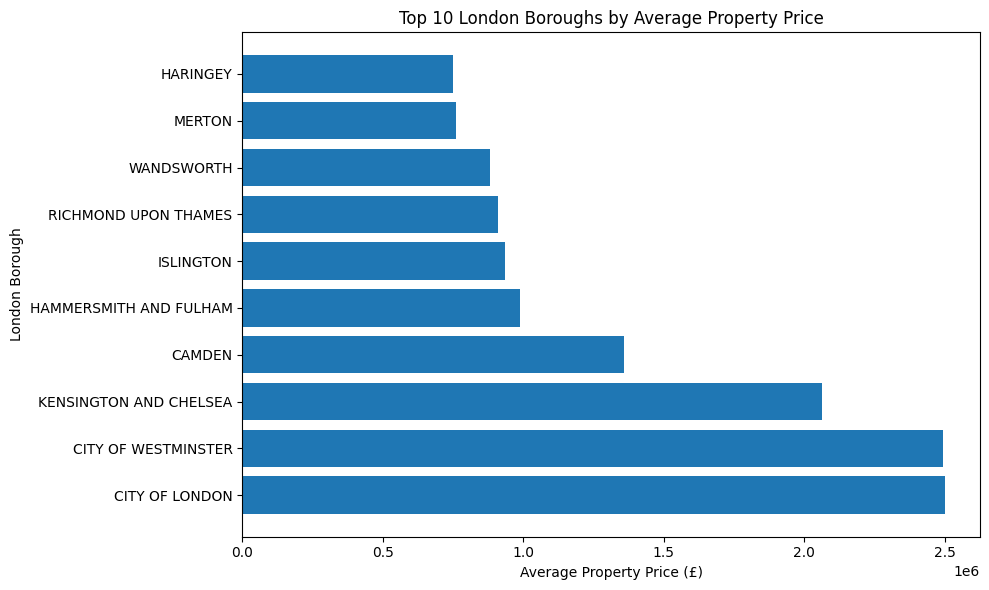

In [22]:
plt.figure(figsize=(10, 6))

plt.barh(
    top10_price["Borough"],
    top10_price["Average Price"]
)

plt.title("Top 10 London Boroughs by Average Property Price")
plt.xlabel("Average Property Price (£)")
plt.ylabel("London Borough")

plt.tight_layout()

plt.show()

### Insight

The highest average property prices are concentrated in Central London boroughs, with the City of London, the City of Westminster, and Kensington and Chelsea ranking at the top.

A noticeable price gap exists between the top three boroughs and the remaining boroughs, suggesting that London's premium property market is highly concentrated in a relatively small number of central locations.

Average property price alone does not fully describe market attractiveness. It should be interpreted alongside transaction activity to provide a more balanced understanding of each borough's property market.

## Business Question 3

Which London boroughs offer the best balance between property value and market activity?

### Why does this matter?

Investors need to consider both property prices and market activity when evaluating potential locations. High property prices may indicate premium markets, while strong transaction activity may suggest greater market liquidity and demand. Considering both factors provides a more balanced view of investment opportunities across London boroughs.

### Expected outcome

Identify boroughs that demonstrate a strong combination of average property prices and transaction activity.

In [23]:
market_summary = pd.merge(
    borough_activity,
    average_price,
    on="Borough"
)

market_summary.head()

,Borough,Transactions,Average Price
0,WANDSWORTH,5383,883358.735278
1,CROYDON,4914,485606.624746
2,BROMLEY,4831,603073.537156
3,BARNET,4420,713568.544570
4,LAMBETH,4220,692186.163981


In [24]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

market_summary["Transactions Scaled"] = scaler.fit_transform(
    market_summary[["Transactions"]]
)

market_summary.head()

,Borough,Transactions,Average Price,Transactions Scaled
0,WANDSWORTH,5383,883358.735278,1.000000
1,CROYDON,4914,485606.624746,0.909144
2,BROMLEY,4831,603073.537156,0.893065
3,BARNET,4420,713568.544570,0.813444
4,LAMBETH,4220,692186.163981,0.774700


In [25]:
market_summary["Price Scaled"] = scaler.fit_transform(
    market_summary[["Average Price"]]
)

market_summary.head()

,Borough,Transactions,Average Price,Transactions Scaled,Price Scaled
0,WANDSWORTH,5383,883358.735278,1.000000,0.230487
1,CROYDON,4914,485606.624746,0.909144,0.041210
2,BROMLEY,4831,603073.537156,0.893065,0.097108
3,BARNET,4420,713568.544570,0.813444,0.149689
4,LAMBETH,4220,692186.163981,0.774700,0.139514


In [26]:
market_summary[["Borough", "Average Price", "Price Scaled"]].head(10)

,Borough,Average Price,Price Scaled
0,WANDSWORTH,883358.735278,0.230487
1,CROYDON,485606.624746,0.041210
2,BROMLEY,603073.537156,0.097108
3,BARNET,713568.544570,0.149689
4,LAMBETH,692186.163981,0.139514
5,HAVERING,484541.085257,0.040703
6,EALING,670123.947819,0.129015
7,LEWISHAM,547148.534110,0.070496
8,SOUTHWARK,745361.261911,0.164818
9,WALTHAM FOREST,724221.818693,0.154759


In [27]:
market_summary.sort_values(
    by="Average Price",
    ascending=False
).head(10)

,Borough,Transactions,Average Price,Transactions Scaled,Price Scaled
32,CITY OF LONDON,221,2.500437e+06,0.000000,1.000000
18,CITY OF WESTMINSTER,2814,2.492617e+06,0.502325,0.996279
30,KENSINGTON AND CHELSEA,2049,2.062984e+06,0.354126,0.791831
26,CAMDEN,2380,1.359320e+06,0.418249,0.456981
24,HAMMERSMITH AND FULHAM,2575,9.892811e+05,0.456025,0.280892
27,ISLINGTON,2244,9.337886e+05,0.391902,0.254485
15,RICHMOND UPON THAMES,2917,9.094239e+05,0.522278,0.242890
0,WANDSWORTH,5383,8.833587e+05,1.000000,0.230487
23,MERTON,2630,7.608597e+05,0.466680,0.172194
16,HARINGEY,2887,7.506662e+05,0.516466,0.167343


In [28]:
import numpy as np

market_summary["Log Average Price"] = np.log(
    market_summary["Average Price"]
)

market_summary.head()

,Borough,Transactions,Average Price,Transactions Scaled,Price Scaled,Log Average Price
0,WANDSWORTH,5383,883358.735278,1.000000,0.230487,13.691487
1,CROYDON,4914,485606.624746,0.909144,0.041210,13.093154
2,BROMLEY,4831,603073.537156,0.893065,0.097108,13.309794
3,BARNET,4420,713568.544570,0.813444,0.149689,13.478034
4,LAMBETH,4220,692186.163981,0.774700,0.139514,13.447610


In [29]:
market_summary["Log Price Scaled"] = scaler.fit_transform(
    market_summary[["Log Average Price"]]
)

market_summary.head()

,Borough,Transactions,Average Price,Transactions Scaled,Price Scaled,Log Average Price,Log Price Scaled
0,WANDSWORTH,5383,883358.735278,1.000000,0.230487,13.691487,0.433051
1,CROYDON,4914,485606.624746,0.909144,0.041210,13.093154,0.107027
2,BROMLEY,4831,603073.537156,0.893065,0.097108,13.309794,0.225071
3,BARNET,4420,713568.544570,0.813444,0.149689,13.478034,0.316743
4,LAMBETH,4220,692186.163981,0.774700,0.139514,13.447610,0.300165


## Feature Engineering: Handling Property Price Skewness

### Problemُ

Average property prices showed a strong right-skewed distribution, mainly due to a few premium central London boroughs with extremely high prices.

Examples:
- City of London
- City of Westminster
- Kensington and Chelsea

Using raw prices directly could make these areas dominate the scoring process.

### Approach

I applied a log transformation to the Average Price feature before scaling.

Transformation:

Average Price → Log Average Price → Log Price Scaled

### Reason

The log transformation reduces the impact of extreme values while keeping the relative ranking of boroughs.

For the Market Opportunity Score, Log Price Scaled will be used instead of the original Price Scaled feature.

In [30]:
market_summary.sort_values(
    by="Log Price Scaled",
    ascending=False
).head(10)

,Borough,Transactions,Average Price,Transactions Scaled,Price Scaled,Log Average Price,Log Price Scaled
32,CITY OF LONDON,221,2.500437e+06,0.000000,1.000000,14.731976,1.000000
18,CITY OF WESTMINSTER,2814,2.492617e+06,0.502325,0.996279,14.728844,0.998293
30,KENSINGTON AND CHELSEA,2049,2.062984e+06,0.354126,0.791831,14.539664,0.895212
26,CAMDEN,2380,1.359320e+06,0.418249,0.456981,14.122495,0.667902
24,HAMMERSMITH AND FULHAM,2575,9.892811e+05,0.456025,0.280892,13.804734,0.494758
27,ISLINGTON,2244,9.337886e+05,0.391902,0.254485,13.747005,0.463302
15,RICHMOND UPON THAMES,2917,9.094239e+05,0.522278,0.242890,13.720567,0.448896
0,WANDSWORTH,5383,8.833587e+05,1.000000,0.230487,13.691487,0.433051
23,MERTON,2630,7.608597e+05,0.466680,0.172194,13.542204,0.351709
16,HARINGEY,2887,7.506662e+05,0.516466,0.167343,13.528716,0.344359


## Checking Log Price Scaling

After applying log transformation and scaling, the highest-value boroughs were reviewed to confirm that premium areas still maintain higher scores while reducing the impact of extreme prices.

In [31]:
market_summary["Market Opportunity Score"] = (
    0.5 * market_summary["Transactions Scaled"]
    +
    0.5 * market_summary["Log Price Scaled"]
)

market_summary.head()

,Borough,Transactions,Average Price,Transactions Scaled,Price Scaled,Log Average Price,Log Price Scaled,Market Opportunity Score
0,WANDSWORTH,5383,883358.735278,1.000000,0.230487,13.691487,0.433051,0.716525
1,CROYDON,4914,485606.624746,0.909144,0.041210,13.093154,0.107027,0.508085
2,BROMLEY,4831,603073.537156,0.893065,0.097108,13.309794,0.225071,0.559068
3,BARNET,4420,713568.544570,0.813444,0.149689,13.478034,0.316743,0.565094
4,LAMBETH,4220,692186.163981,0.774700,0.139514,13.447610,0.300165,0.537433


## Creating Market Opportunity Score

To identify boroughs with better investment opportunities, two factors were combined:

- Market activity: Transactions Scaled
- Property value: Log Price Scaled

Both features were given equal importance (50% each) because the objective is to find a balance between market activity and property value rather than focusing only on premium locations.

### Formula

Market Opportunity Score =
0.5 × Transactions Scaled +
0.5 × Log Price Scaled

In [32]:
market_summary_sorted = market_summary.sort_values(
    by="Market Opportunity Score",
    ascending=False
)

market_summary_sorted.head(10)

,Borough,Transactions,Average Price,Transactions Scaled,Price Scaled,Log Average Price,Log Price Scaled,Market Opportunity Score
18,CITY OF WESTMINSTER,2814,2.492617e+06,0.502325,0.996279,14.728844,0.998293,0.750309
0,WANDSWORTH,5383,8.833587e+05,1.000000,0.230487,13.691487,0.433051,0.716525
30,KENSINGTON AND CHELSEA,2049,2.062984e+06,0.354126,0.791831,14.539664,0.895212,0.624669
3,BARNET,4420,7.135685e+05,0.813444,0.149689,13.478034,0.316743,0.565094
2,BROMLEY,4831,6.030735e+05,0.893065,0.097108,13.309794,0.225071,0.559068
26,CAMDEN,2380,1.359320e+06,0.418249,0.456981,14.122495,0.667902,0.543075
4,LAMBETH,4220,6.921862e+05,0.774700,0.139514,13.447610,0.300165,0.537433
1,CROYDON,4914,4.856066e+05,0.909144,0.041210,13.093154,0.107027,0.508085
32,CITY OF LONDON,221,2.500437e+06,0.000000,1.000000,14.731976,1.000000,0.500000
8,SOUTHWARK,3589,7.453613e+05,0.652460,0.164818,13.521624,0.340495,0.496478


## Ranking Boroughs by Market Opportunity Score

Boroughs were ranked based on the Market Opportunity Score, which combines property value and market activity.

The ranking should be interpreted as an initial market opportunity indicator based on available transaction data, rather than a complete investment recommendation.

Additional factors such as rental yield, price growth, and economic indicators would be required for a more comprehensive investment analysis.

In [33]:
top_boroughs = market_summary_sorted.head(10)

top_boroughs

,Borough,Transactions,Average Price,Transactions Scaled,Price Scaled,Log Average Price,Log Price Scaled,Market Opportunity Score
18,CITY OF WESTMINSTER,2814,2.492617e+06,0.502325,0.996279,14.728844,0.998293,0.750309
0,WANDSWORTH,5383,8.833587e+05,1.000000,0.230487,13.691487,0.433051,0.716525
30,KENSINGTON AND CHELSEA,2049,2.062984e+06,0.354126,0.791831,14.539664,0.895212,0.624669
3,BARNET,4420,7.135685e+05,0.813444,0.149689,13.478034,0.316743,0.565094
2,BROMLEY,4831,6.030735e+05,0.893065,0.097108,13.309794,0.225071,0.559068
26,CAMDEN,2380,1.359320e+06,0.418249,0.456981,14.122495,0.667902,0.543075
4,LAMBETH,4220,6.921862e+05,0.774700,0.139514,13.447610,0.300165,0.537433
1,CROYDON,4914,4.856066e+05,0.909144,0.041210,13.093154,0.107027,0.508085
32,CITY OF LONDON,221,2.500437e+06,0.000000,1.000000,14.731976,1.000000,0.500000
8,SOUTHWARK,3589,7.453613e+05,0.652460,0.164818,13.521624,0.340495,0.496478


In [34]:
top_boroughs_plot = top_boroughs[
    ["Borough", "Market Opportunity Score"]
]

top_boroughs_plot

,Borough,Market Opportunity Score
18,CITY OF WESTMINSTER,0.750309
0,WANDSWORTH,0.716525
30,KENSINGTON AND CHELSEA,0.624669
3,BARNET,0.565094
2,BROMLEY,0.559068
26,CAMDEN,0.543075
4,LAMBETH,0.537433
1,CROYDON,0.508085
32,CITY OF LONDON,0.500000
8,SOUTHWARK,0.496478


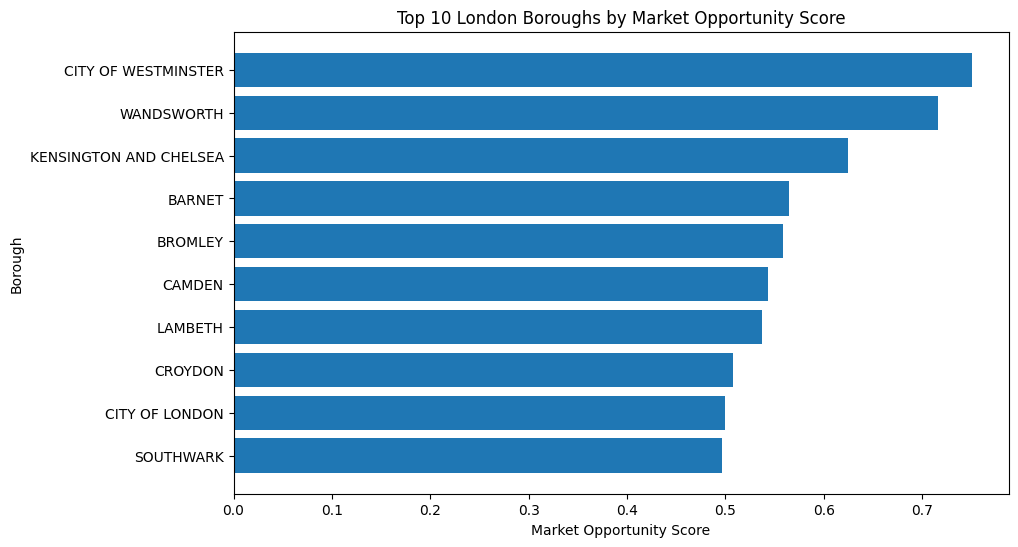

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    top_boroughs_plot["Borough"],
    top_boroughs_plot["Market Opportunity Score"]
)

plt.xlabel("Market Opportunity Score")
plt.ylabel("Borough")
plt.title("Top 10 London Boroughs by Market Opportunity Score")

plt.gca().invert_yaxis()

plt.show()

## Visualising Top Market Opportunities

The top 10 boroughs were visualised based on the Market Opportunity Score to highlight areas with a stronger balance between property value and market activity.

In [36]:
id="k2m8p"
top_boroughs_analysis = market_summary_sorted.head(10)[
    [
        "Borough",
        "Transactions",
        "Average Price",
        "Market Opportunity Score"
    ]
]

top_boroughs_analysis

,Borough,Transactions,Average Price,Market Opportunity Score
18,CITY OF WESTMINSTER,2814,2.492617e+06,0.750309
0,WANDSWORTH,5383,8.833587e+05,0.716525
30,KENSINGTON AND CHELSEA,2049,2.062984e+06,0.624669
3,BARNET,4420,7.135685e+05,0.565094
2,BROMLEY,4831,6.030735e+05,0.559068
26,CAMDEN,2380,1.359320e+06,0.543075
4,LAMBETH,4220,6.921862e+05,0.537433
1,CROYDON,4914,4.856066e+05,0.508085
32,CITY OF LONDON,221,2.500437e+06,0.500000
8,SOUTHWARK,3589,7.453613e+05,0.496478


## Sensitivity Analysis: Testing Different Feature Weights

The initial Market Opportunity Score used equal weights for market activity and property value (50/50).

To understand how sensitive the ranking is to different priorities, alternative weighting scenarios are tested.

For example, an activity-focused scenario gives more importance to transaction volume:

70% Market Activity  
30% Property Value

This helps evaluate whether the identified opportunities remain consistent under different investment preferences.

In [37]:
market_summary["Activity Focused Score"] = (
    0.7 * market_summary["Transactions Scaled"]
    +
    0.3 * market_summary["Log Price Scaled"]
)

market_summary.sort_values(
    by="Activity Focused Score",
    ascending=False
).head(10)

,Borough,Transactions,Average Price,Transactions Scaled,Price Scaled,Log Average Price,Log Price Scaled,Market Opportunity Score,Activity Focused Score
0,WANDSWORTH,5383,8.833587e+05,1.000000,0.230487,13.691487,0.433051,0.716525,0.829915
2,BROMLEY,4831,6.030735e+05,0.893065,0.097108,13.309794,0.225071,0.559068,0.692667
1,CROYDON,4914,4.856066e+05,0.909144,0.041210,13.093154,0.107027,0.508085,0.668509
3,BARNET,4420,7.135685e+05,0.813444,0.149689,13.478034,0.316743,0.565094,0.664434
18,CITY OF WESTMINSTER,2814,2.492617e+06,0.502325,0.996279,14.728844,0.998293,0.750309,0.651115
4,LAMBETH,4220,6.921862e+05,0.774700,0.139514,13.447610,0.300165,0.537433,0.632339
8,SOUTHWARK,3589,7.453613e+05,0.652460,0.164818,13.521624,0.340495,0.496478,0.558871
6,EALING,3622,6.701239e+05,0.658853,0.129015,13.415218,0.282515,0.470684,0.545952
9,WALTHAM FOREST,3381,7.242218e+05,0.612166,0.154759,13.492853,0.324818,0.468492,0.525961
30,KENSINGTON AND CHELSEA,2049,2.062984e+06,0.354126,0.791831,14.539664,0.895212,0.624669,0.516452


## Sensitivity Analysis Result

Changing the feature weights affected the ranking of boroughs.

When market activity received higher importance (70/30 scenario), highly active markets such as Wandsworth, Bromley, and Croydon moved higher in the ranking.

This demonstrates that the Market Opportunity Score reflects different investor priorities rather than representing a single universal ranking.

In [38]:
score_comparison = market_summary[
    [
        "Borough",
        "Market Opportunity Score",
        "Activity Focused Score"
    ]
]


In [39]:
market_summary["Robust Opportunity Score"] = (
    market_summary["Market Opportunity Score"]
    +
    market_summary["Activity Focused Score"]
) / 2

market_summary.sort_values(
    by="Robust Opportunity Score",
    ascending=False
).head(10)

,Borough,Transactions,Average Price,Transactions Scaled,Price Scaled,Log Average Price,Log Price Scaled,Market Opportunity Score,Activity Focused Score,Robust Opportunity Score
0,WANDSWORTH,5383,8.833587e+05,1.000000,0.230487,13.691487,0.433051,0.716525,0.829915,0.773220
18,CITY OF WESTMINSTER,2814,2.492617e+06,0.502325,0.996279,14.728844,0.998293,0.750309,0.651115,0.700712
2,BROMLEY,4831,6.030735e+05,0.893065,0.097108,13.309794,0.225071,0.559068,0.692667,0.625867
3,BARNET,4420,7.135685e+05,0.813444,0.149689,13.478034,0.316743,0.565094,0.664434,0.614764
1,CROYDON,4914,4.856066e+05,0.909144,0.041210,13.093154,0.107027,0.508085,0.668509,0.588297
4,LAMBETH,4220,6.921862e+05,0.774700,0.139514,13.447610,0.300165,0.537433,0.632339,0.584886
30,KENSINGTON AND CHELSEA,2049,2.062984e+06,0.354126,0.791831,14.539664,0.895212,0.624669,0.516452,0.570560
8,SOUTHWARK,3589,7.453613e+05,0.652460,0.164818,13.521624,0.340495,0.496478,0.558871,0.527674
26,CAMDEN,2380,1.359320e+06,0.418249,0.456981,14.122495,0.667902,0.543075,0.493145,0.518110
6,EALING,3622,6.701239e+05,0.658853,0.129015,13.415218,0.282515,0.470684,0.545952,0.508318


## Robust Opportunity Score

To identify boroughs that remain strong under different investor preferences, a Robust Opportunity Score was created.

This score represents the average performance across two scenarios:

- Balanced scenario (50% market activity, 50% property value)
- Activity-focused scenario (70% market activity, 30% property value)

Boroughs with higher Robust Opportunity Scores demonstrate more consistent performance across different investment priorities.

In [40]:
top_robust_boroughs = market_summary.sort_values(
    by="Robust Opportunity Score",
    ascending=False
).head(10)

top_robust_boroughs

,Borough,Transactions,Average Price,Transactions Scaled,Price Scaled,Log Average Price,Log Price Scaled,Market Opportunity Score,Activity Focused Score,Robust Opportunity Score
0,WANDSWORTH,5383,8.833587e+05,1.000000,0.230487,13.691487,0.433051,0.716525,0.829915,0.773220
18,CITY OF WESTMINSTER,2814,2.492617e+06,0.502325,0.996279,14.728844,0.998293,0.750309,0.651115,0.700712
2,BROMLEY,4831,6.030735e+05,0.893065,0.097108,13.309794,0.225071,0.559068,0.692667,0.625867
3,BARNET,4420,7.135685e+05,0.813444,0.149689,13.478034,0.316743,0.565094,0.664434,0.614764
1,CROYDON,4914,4.856066e+05,0.909144,0.041210,13.093154,0.107027,0.508085,0.668509,0.588297
4,LAMBETH,4220,6.921862e+05,0.774700,0.139514,13.447610,0.300165,0.537433,0.632339,0.584886
30,KENSINGTON AND CHELSEA,2049,2.062984e+06,0.354126,0.791831,14.539664,0.895212,0.624669,0.516452,0.570560
8,SOUTHWARK,3589,7.453613e+05,0.652460,0.164818,13.521624,0.340495,0.496478,0.558871,0.527674
26,CAMDEN,2380,1.359320e+06,0.418249,0.456981,14.122495,0.667902,0.543075,0.493145,0.518110
6,EALING,3622,6.701239e+05,0.658853,0.129015,13.415218,0.282515,0.470684,0.545952,0.508318


In [41]:
top_robust_plot = top_robust_boroughs[
    ["Borough", "Robust Opportunity Score"]
]

top_robust_plot

,Borough,Robust Opportunity Score
0,WANDSWORTH,0.773220
18,CITY OF WESTMINSTER,0.700712
2,BROMLEY,0.625867
3,BARNET,0.614764
1,CROYDON,0.588297
4,LAMBETH,0.584886
30,KENSINGTON AND CHELSEA,0.570560
8,SOUTHWARK,0.527674
26,CAMDEN,0.518110
6,EALING,0.508318


## Final Ranking: Robust Market Opportunities

The final ranking is based on the Robust Opportunity Score, which combines multiple investor perspectives.

This metric identifies boroughs that maintain strong performance across different weighting scenarios, providing a more stable view of potential market opportunities.

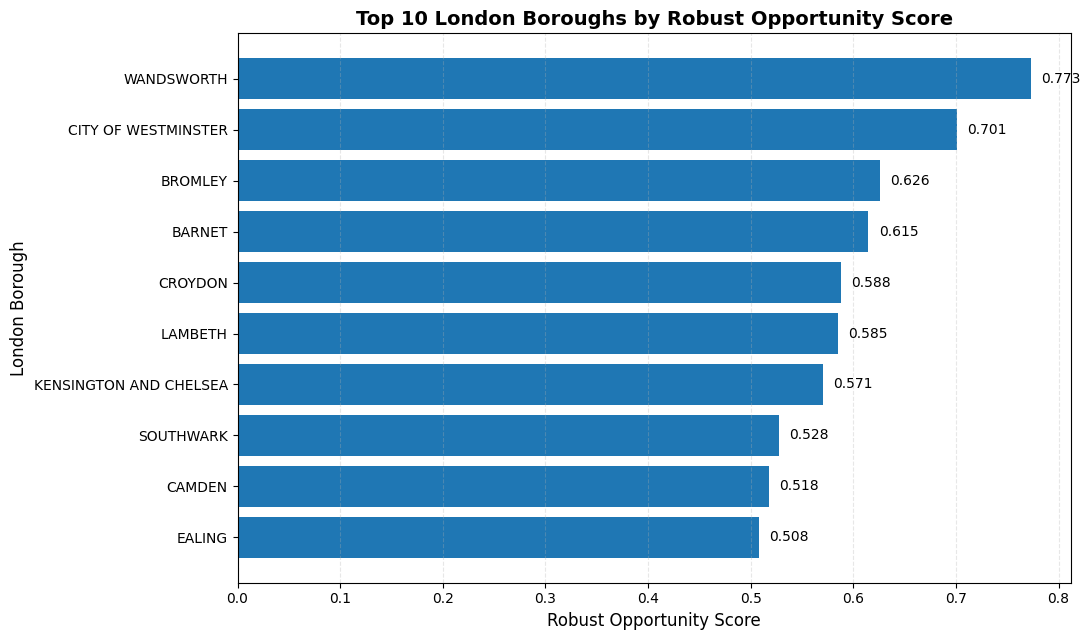

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6.5))

bars = plt.barh(
    top_robust_plot["Borough"],
    top_robust_plot["Robust Opportunity Score"]
)

plt.xlabel("Robust Opportunity Score", fontsize=12)
plt.ylabel("London Borough", fontsize=12)
plt.title(
    "Top 10 London Boroughs by Robust Opportunity Score",
    fontsize=14,
    fontweight="bold"
)

# Highest score at the top
plt.gca().invert_yaxis()

# Light grid for easier reading
plt.grid(axis="x", linestyle="--", alpha=0.3)

# Add score labels
for bar in bars:
    score = bar.get_width()
    plt.text(
        score + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{score:.3f}",
        va="center",
        fontsize=10
    )

plt.tight_layout()

# Save high-quality image for README
plt.savefig(
    "../visuals/robust_opportunity_score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Question 3 — Final Insight

The analysis aimed to identify London boroughs that provide a strong balance between property value and market activity.

A Market Opportunity Score was developed by combining transaction volume and property value. To improve the robustness of the ranking, sensitivity analysis was performed by testing different feature weight combinations.

The final Robust Opportunity Score identified boroughs that maintained strong performance across different investor preferences.

Wandsworth achieved the highest Robust Opportunity Score, reflecting a strong combination of market activity and property value across the evaluated scenarios. City of Westminster also showed strong performance, mainly driven by its premium property values.

Other boroughs such as Bromley, Barnet, and Croydon demonstrated strong market activity combined with more moderate property prices, highlighting different types of potential market opportunities.

These results should be interpreted as an initial market opportunity indicator based on transaction activity and property prices. Additional factors such as rental yield, price growth, economic indicators, and local characteristics would be required for a comprehensive investment analysis.

# Project Summary

## Key Findings

This analysis explored London property transactions using HM Land Registry data to identify boroughs with different market characteristics.

The project combined exploratory data analysis, feature engineering, and business-driven scoring to evaluate investment opportunities from multiple perspectives.

### Main outcomes

- Wandsworth demonstrated the strongest overall balance between market activity and property value.
- Premium central boroughs such as the City of Westminster and Kensington and Chelsea achieved high scores because of their exceptionally high property values.
- Sensitivity analysis showed that borough rankings vary depending on investor priorities, highlighting the importance of considering different investment strategies.
- The Robust Opportunity Score identified boroughs that consistently performed well across different weighting scenarios.

### Project limitations

This analysis is based on property transaction activity and average sale prices only.

Additional variables such as rental yield, historical price growth, demographic trends, interest rates, and local economic indicators would further improve investment decision-making.

### Next Steps

Future versions of this project could incorporate additional datasets and develop an interactive dashboard for exploring London property markets.

In [43]:
print("london_df columns:")
print(london_df.columns.tolist())

london_df columns:
['Transaction unique identifier', 'Price', 'Date of Transfer', 'Postcode', 'Property Type', 'Old/New', 'Duration', 'PAON', 'SAON', 'Street', 'Locality', 'Town/City', 'District', 'County', 'PPD Category Type', 'Record Status']


In [44]:
# Inspect DataFrame objects currently available

print([
    name
    for name, obj in globals().items()
    if hasattr(obj, "columns")
])

['_', '__', '___', 'df', '_3', '_5', 'london_df', '_7', 'saved_df', '_12', 'borough_activity', '_15', 'top10', 'average_price', '_19', '_20', 'top10_price', '_21', 'market_summary', '_23', '_24', '_25', '_26', '_27', '_28', '_29', '_30', '_31', 'market_summary_sorted', '_32', 'top_boroughs', '_33', 'top_boroughs_plot', '_34', 'top_boroughs_analysis', '_36', '_37', 'score_comparison', '_39', 'top_robust_boroughs', '_40', 'top_robust_plot', '_41']
